<a href="https://colab.research.google.com/github/Dandyeriametor/Activity/blob/main/Assignment_7_House_Price_Prediction_Using_Boston_Housing_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 7: House Price Prediction Using Boston Housing Data

Author: Dandy Eriametor

Business Intelligence Analyst

Student Number: DE111080

#House Price Prediction Using Boston Housing Dataset

Complete ML workflow:
  
  → Data loading
  
  → EDA
  
  → Model building (Decision Tree / Random Forest)
  
  → Evaluation
  
  → Parameter tuning
  
  → Prediction

In [1]:
# Task 1: Import all required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Visualization settings
sns.set(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (6, 4)

In [2]:
# Task 2:Data Collection and Loading
# Boston Housing dataset (UCI version hosted on GitHub)
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)

# Normalize column names to uppercase to avoid KeyErrors
df.columns = [col.strip().upper() for col in df.columns]

print(" Boston Housing Dataset Loaded Successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# Preview
df.head()

 Boston Housing Dataset Loaded Successfully!
Shape: (506, 14)
Columns: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [3]:
# Task 3: Quick Check of Data
print("\n--- Dataset Info ---")
df.info()

print("\n--- Statistical Summary ---")
display(df.describe())


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB

--- Statistical Summary ---


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000



--- Missing Values ---
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


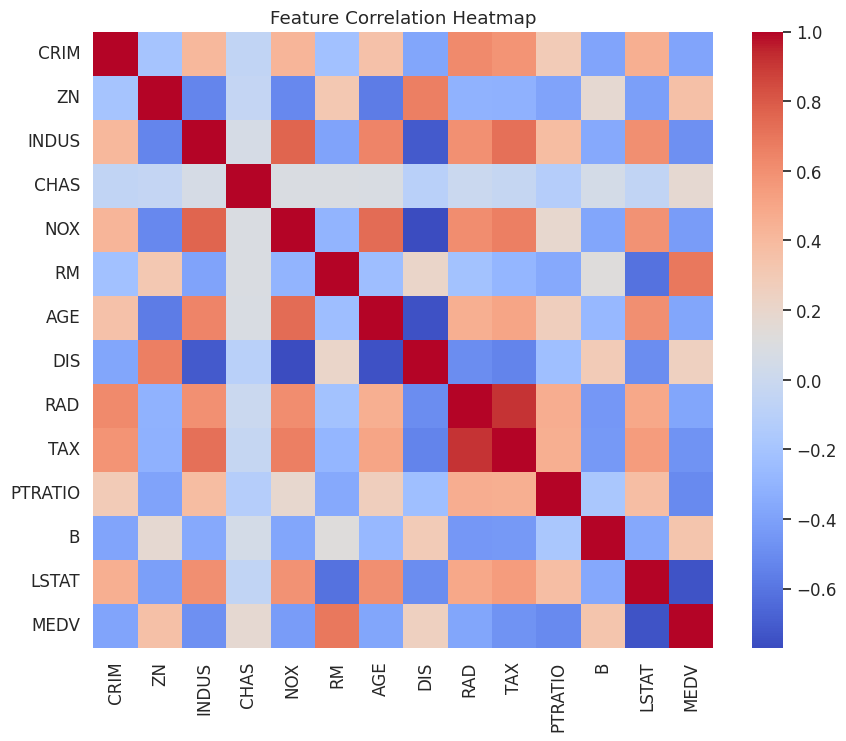

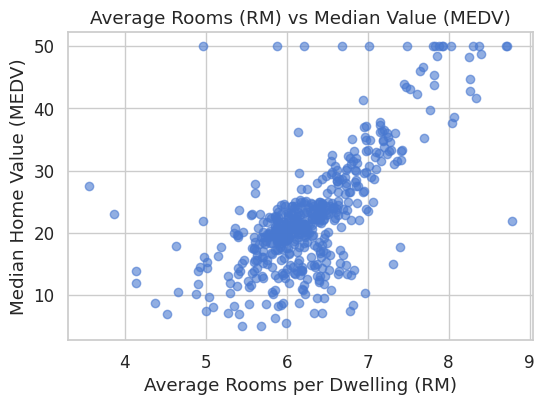

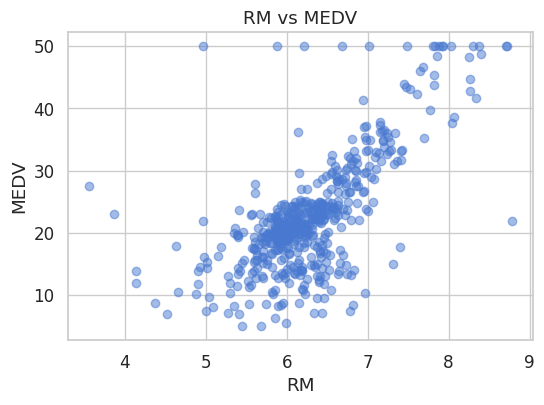

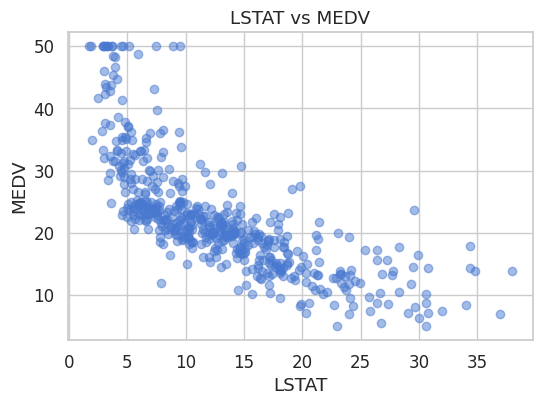

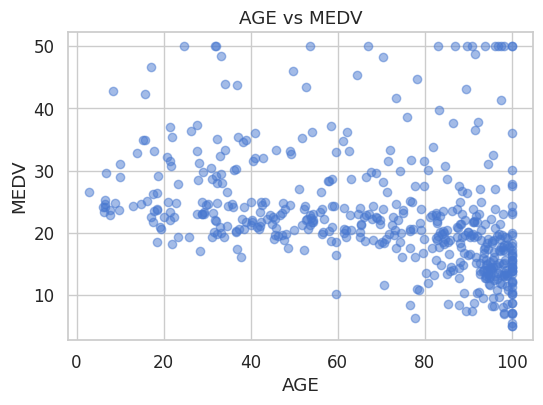

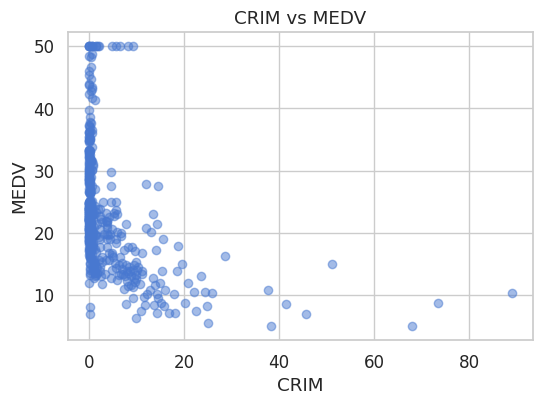

In [4]:
# Task 4: EDA and Data Preprocessing
# Check for missing/null values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

# Example scatter plot
plt.scatter(df["RM"], df["MEDV"], alpha=0.6)
plt.title("Average Rooms (RM) vs Median Value (MEDV)")
plt.xlabel("Average Rooms per Dwelling (RM)")
plt.ylabel("Median Home Value (MEDV)")
plt.show()

# Function to automate scatter plots
def plot_feature_vs_target(data, features, target="MEDV"):
    """Plot scatter plots of multiple features vs the target variable."""
    for feature in features:
        plt.scatter(data[feature], data[target], alpha=0.5)
        plt.title(f"{feature} vs {target}")
        plt.xlabel(feature)
        plt.ylabel(target)
        plt.show()

# Use the function to visualize relationships
features_to_plot = ["RM", "LSTAT", "AGE", "CRIM"]
plot_feature_vs_target(df, features_to_plot, "MEDV")

In [5]:
# Task 5: ML Model Training
# Split dataset
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

# Choose model
# model = DecisionTreeRegressor(random_state=42)
model = RandomForestRegressor(random_state=42)

# Train the model
model.fit(X_train, y_train)
print("\n Model Training Completed!")

Training samples: 404
Testing samples: 102

 Model Training Completed!



--- Model Evaluation ---
Root Mean Squared Error (RMSE): 2.811
R-squared (R²): 0.892


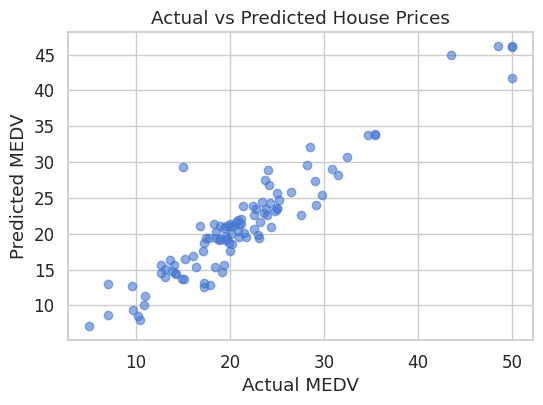

In [6]:
# Task 6: Model Evaluation
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R-squared (R²): {r2:.3f}")

# Plot predicted vs actual
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [7]:
# 6️ Parameter Tuning (Optional)
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print("\n Best Parameters Found:")
print(grid_search.best_params_)
print(f"Best Cross-Validation R²: {grid_search.best_score_:.3f}")

# Evaluate tuned model
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)

print("\n--- Tuned Model Evaluation ---")
print(f"RMSE (Tuned): {rmse_best:.3f}")
print(f"R² (Tuned): {r2_best:.3f}")

Fitting 3 folds for each of 27 candidates, totalling 81 fits

 Best Parameters Found:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}
Best Cross-Validation R²: 0.818

--- Tuned Model Evaluation ---
RMSE (Tuned): 2.724
R² (Tuned): 0.899


In [8]:
# Task 7: Model Prediction on New Data
new_data = pd.DataFrame({
    "CRIM": [0.2],
    "ZN": [12.5],
    "INDUS": [7.07],
    "CHAS": [0],
    "NOX": [0.5],
    "RM": [6.5],
    "AGE": [68],
    "DIS": [4.0],
    "RAD": [2],
    "TAX": [250],
    "PTRATIO": [17],
    "B": [400],
    "LSTAT": [12]
})

predicted_price = best_model.predict(new_data)
print("\n--- Prediction for New Data ---")
print(f"Predicted Median House Value: ${predicted_price[0]*1000:.2f}")


--- Prediction for New Data ---
Predicted Median House Value: $21823.89
